<a href="https://colab.research.google.com/github/Hackathon-05-06-2026/Hackathon_Files/blob/main/%20Group_R_LSTM%20modelling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [70]:
from google.colab import drive
import pandas as pd
import numpy as np
import glob
import re
import os
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# Install and import Keras Tuner packages
!pip install -q -U keras-tuner
import keras_tuner as kt

print(" Step 1: Connecting to Google Drive...")
drive.mount('/content/drive')

 Step 1: Connecting to Google Drive...
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [60]:

# 2. LOCATE AND LOAD THE SUPER-DATASET-COVID_VACCINE

print("\n Step 2: Loading preprocessed Super-Dataset...")
search_pattern = '/content/drive/MyDrive/*Dataset*C*/super_dataset_C_train.csv'
matching_files = glob.glob(search_pattern)

if len(matching_files) == 0:
    matching_files = glob.glob('/content/drive/MyDrive/Hackathon_05*06/super_dataset_C_train.csv')

if len(matching_files) > 0:
    file_path = matching_files[0]
    df_super = pd.read_csv(file_path)
    print(f" SUCCESS! Loaded dataset from: {file_path}")
else:
    raise FileNotFoundError(" ERROR: Could not find 'super_dataset_C_train.csv'.")

# Clean column headers
df_super.columns = [re.sub(r'[\[\]<>]', '', col) for col in df_super.columns]

# Split features and labels
y_model = df_super['covid_vaccine'].values
X_model = df_super.drop(columns=['covid_vaccine']).values

X_train, X_val, y_train, y_val = train_test_split(
    X_model, y_model, test_size=0.2, random_state=42, stratify=y_model
)

# Reshape into 3D format [samples, time_steps, features] for LSTM
X_train_lstm = np.reshape(X_train, (X_train.shape[0], 1, X_train.shape[1]))
X_val_lstm = np.reshape(X_val, (X_val.shape[0], 1, X_val.shape[1]))

# Account for 2:1 class imbalance
class_weights = {0: 1.0, 1: 2.0}



 Step 2: Loading preprocessed Super-Dataset...
 SUCCESS! Loaded dataset from: /content/drive/MyDrive/Hackathon_05 06/super_dataset_C_train.csv


In [61]:
print("  Basic LSTM Model (Before Tuning) Architecture   ")

basic_lstm_model = Sequential()
basic_lstm_model.add(LSTM(units=64, input_shape=(1, X_train.shape[1]), return_sequences=False))
basic_lstm_model.add(Dropout(rate=0.2)) # Example dropout rate
basic_lstm_model.add(Dense(units=32, activation='relu'))
basic_lstm_model.add(Dropout(rate=0.2)) # Example dropout rate
basic_lstm_model.add(Dense(1, activation='sigmoid'))

# Compile with a common learning rate
basic_lstm_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=[tf.keras.metrics.AUC(name='auc')]
)

basic_lstm_model.summary()


================  Basic LSTM Model (Before Tuning) Architecture  ================ 


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_5 (LSTM)                   │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 35,137 (137.25 KB)

 Trainable params: 35,137 (137.25 KB)

 Non-trainable params: 0 (0.00 B)

In [62]:

# 3. DEFINE THE HP TUNING MODEL BUILDER

def build_model(hp):
    model = Sequential()

    # Tune the number of hidden units in the LSTM layer
    hp_units = hp.Int('lstm_units', min_value=32, max_value=128, step=32)
    model.add(LSTM(units=hp_units, input_shape=(1, X_train.shape[1]), return_sequences=False))

    # Tune the dropout rate to optimize regularization
    hp_dropout_1 = hp.Float('dropout_1', min_value=0.1, max_value=0.5, step=0.1)
    model.add(Dropout(rate=hp_dropout_1))

    # Intermediate dense layer
    model.add(Dense(units=32, activation='relu'))

    hp_dropout_2 = hp.Float('dropout_2', min_value=0.1, max_value=0.5, step=0.1)
    model.add(Dropout(rate=hp_dropout_2))

    model.add(Dense(1, activation='sigmoid'))

    # Tune the learning rate for the optimizer
    hp_lr = hp.Choice('learning_rate', values=[1e-2, 1e-3, 1e-4])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=hp_lr),
        loss='binary_crossentropy',
        metrics=[tf.keras.metrics.AUC(name='auc')]
    )

    return model



 Step 3: Initializing RandomSearch optimization engine...
Reloading Tuner from lstm_tuning_dir/vaccine_lstm/tuner0.json
Running Hyperparameter Search trials...

================  OPTIMAL PARAMETERS FOUND ================
 Best LSTM Units: 64
Best Dropout Layer 1: 0.1
Best Dropout Layer 2: 0.1
Best Learning Rate: 0.001

 Training the finalized model using optimal configurations...
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 49ms/step

================  TUNED LSTM EVALUATION REPORT ================ 
 Tuned LSTM Validation ROC-AUC: 0.8260

                    precision    recall  f1-score   support

Not Vaccinated (0)       0.86      0.81      0.83       641
    Vaccinated (1)       0.65      0.73      0.69       311

          accuracy                           0.78       952
         macro avg       0.75      0.77      0.76       952
      weighted avg       0.79      0.78      0.79       952



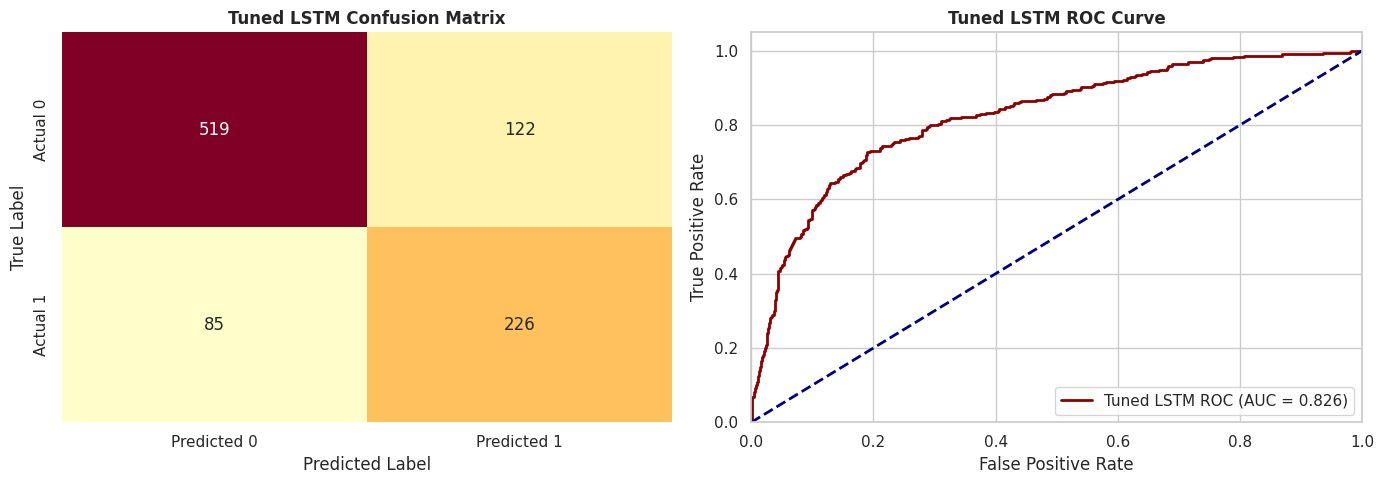


Tuned LSTM charts saved directly to shared Drive folder:
   /content/drive/MyDrive/Hackathon_05 06/team_lstm_tuned_evaluation.png


In [63]:

# 4. INITIALIZE TUNER AND RUN SEARCH

print("\n Step 3: Initializing RandomSearch optimization engine...")
tuner = kt.RandomSearch(
    build_model,
    objective=kt.Objective("val_auc", direction="max"), # Maximize validation ROC-AUC
    max_trials=5, # TestING 5 distinct parameter combinations
    executions_per_trial=1,
    directory='lstm_tuning_dir',
    project_name='vaccine_lstm'
)

# Run early stopping to truncate bad trails early
stop_early = EarlyStopping(monitor='val_loss', patience=3)

print("Running Hyperparameter Search trials...")
tuner.search(
    X_train_lstm, y_train,
    epochs=15,
    validation_data=(X_val_lstm, y_val),
    class_weight=class_weights,
    callbacks=[stop_early],
    verbose=1
)

# Fetch and report the winner combination
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]
print("\n  OPTIMAL PARAMETERS FOUND ")
print(f" Best LSTM Units: {best_hps.get('lstm_units')}")
print(f"Best Dropout Layer 1: {best_hps.get('dropout_1'):.1f}")
print(f"Best Dropout Layer 2: {best_hps.get('dropout_2'):.1f}")
print(f"Best Learning Rate: {best_hps.get('learning_rate')}\n")

#
# 5. TRAIN FINAL BEST MODEL
#
print(" Training the finalized model using optimal configurations...")
best_model = tuner.hypermodel.build(best_hps)
final_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

best_model.fit(
    X_train_lstm, y_train,
    epochs=35,
    batch_size=32,
    validation_data=(X_val_lstm, y_val),
    class_weight=class_weights,
    callbacks=[final_stop],
    verbose=0
)

# 6. EVALUATION AND PLOT GENERATION

y_pred_proba = best_model.predict(X_val_lstm).flatten()
y_pred = (y_pred_proba >= 0.5).astype(int)

print("\n  TUNED LSTM EVALUATION REPORT  ")
tuned_auc = roc_auc_score(y_val, y_pred_proba)
print(f" Tuned LSTM Validation ROC-AUC: {tuned_auc:.4f}\n")
print(classification_report(y_val, y_pred, target_names=['Not Vaccinated (0)', 'Vaccinated (1)']))

# Draw Dashboards
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion Matrix
cm = confusion_matrix(y_val, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='YlOrRd', ax=axes[0], cbar=False,
            xticklabels=['Predicted 0', 'Predicted 1'], yticklabels=['Actual 0', 'Actual 1'])
axes[0].set_title('Tuned LSTM Confusion Matrix', fontweight='bold')
axes[0].set_xlabel('Predicted Label')
axes[0].set_ylabel('True Label')

# ROC Curve
fpr, tpr, _ = roc_curve(y_val, y_pred_proba)
axes[1].plot(fpr, tpr, color='darkred', lw=2, label=f'Tuned LSTM ROC (AUC = {tuned_auc:.3f})')
axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('Tuned LSTM ROC Curve', fontweight='bold')
axes[1].legend(loc="lower right")

plt.tight_layout()

# Save final graphic to your shared Drive
output_plot_path = file_path.replace('super_dataset_C_train.csv', 'team_lstm_tuned_evaluation.png')
plt.savefig(output_plot_path, dpi=300, bbox_inches='tight')
plt.show()

print(f"\nTuned LSTM charts saved directly to shared Drive folder:\n   {output_plot_path}")


================  SVM Model Implementation
Initializing and training SVM Classifier...
SVM training complete.

Evaluating the SVM model...

================  SVM EVALUATION REPORT  ================ 
SVM Validation ROC-AUC: 0.8165

                    precision    recall  f1-score   support

Not Vaccinated (0)       0.85      0.81      0.83       641
    Vaccinated (1)       0.64      0.69      0.66       311

          accuracy                           0.77       952
         macro avg       0.74      0.75      0.75       952
      weighted avg       0.78      0.77      0.77       952



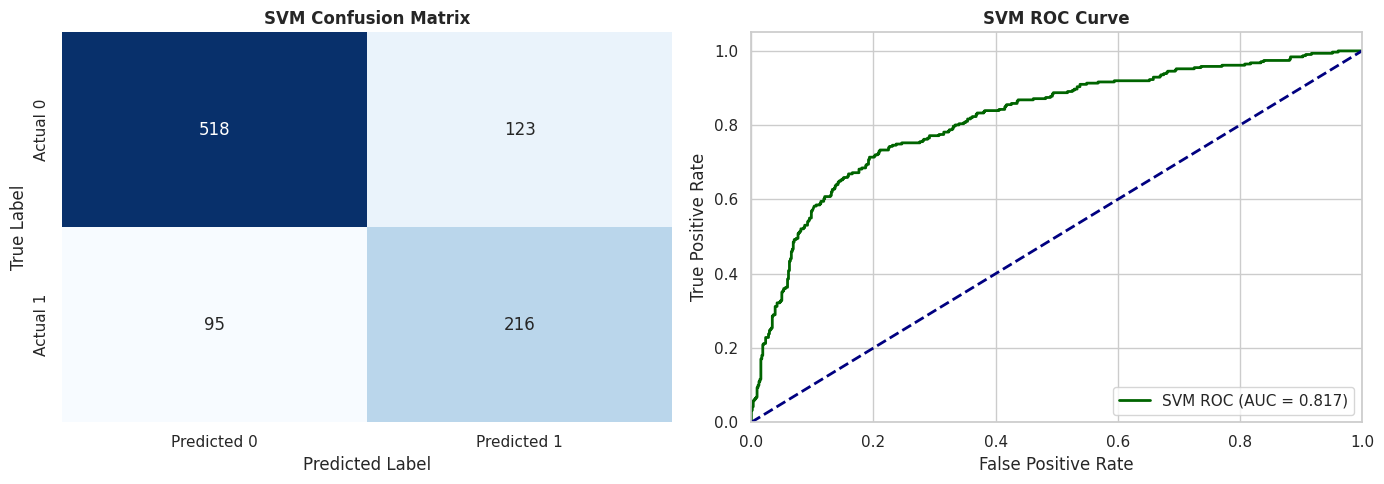


SVM charts saved directly to shared Drive folder:
   /content/drive/MyDrive/Hackathon_05 06/team_svm_evaluation.png


In [64]:
print("\n================  SVM Model Implementation")

# 1. Import necessary libraries for SVM
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

# 2. Data Scaling for SVM (important for distance-based algorithms like SVM)
# It's good practice to scale features for SVM. The data was already somewhat scaled
# during initial preprocessing, but StandardScaler is robust for SVM.
scaler_svm = StandardScaler()
X_train_scaled_svm = scaler_svm.fit_transform(X_train)
X_val_scaled_svm = scaler_svm.transform(X_val)

# 3. Initialize and train the SVM Classifier
print("Initializing and training SVM Classifier...")
# Using class_weight='balanced' to handle the imbalance, similar to what was done for LSTM
svm_model = SVC(probability=True, random_state=42, class_weight='balanced')
svm_model.fit(X_train_scaled_svm, y_train)
print("SVM training complete.")

# 4. Evaluate the SVM model
print("\nEvaluating the SVM model...")
y_pred_svm = svm_model.predict(X_val_scaled_svm)
y_pred_proba_svm = svm_model.predict_proba(X_val_scaled_svm)[:, 1]

print("\n================  SVM EVALUATION REPORT  ================ ")
svm_auc = roc_auc_score(y_val, y_pred_proba_svm)
print(f"SVM Validation ROC-AUC: {svm_auc:.4f}\n")
print(classification_report(y_val, y_pred_svm, target_names=['Not Vaccinated (0)', 'Vaccinated (1)']))

# 5. Draw Dashboards for SVM
sns.set_theme(style="whitegrid")
fig_svm, axes_svm = plt.subplots(1, 2, figsize=(14, 5))

# Confusion Matrix for SVM
cm_svm = confusion_matrix(y_val, y_pred_svm)
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Blues', ax=axes_svm[0], cbar=False,
            xticklabels=['Predicted 0', 'Predicted 1'], yticklabels=['Actual 0', 'Actual 1'])
axes_svm[0].set_title('SVM Confusion Matrix', fontweight='bold')
axes_svm[0].set_xlabel('Predicted Label')
axes_svm[0].set_ylabel('True Label')

# ROC Curve for SVM
fpr_svm, tpr_svm, _ = roc_curve(y_val, y_pred_proba_svm)
axes_svm[1].plot(fpr_svm, tpr_svm, color='darkgreen', lw=2, label=f'SVM ROC (AUC = {svm_auc:.3f})')
axes_svm[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
axes_svm[1].set_xlim([0.0, 1.0])
axes_svm[1].set_ylim([0.0, 1.05])
axes_svm[1].set_xlabel('False Positive Rate')
axes_svm[1].set_ylabel('True Positive Rate')
axes_svm[1].set_title('SVM ROC Curve', fontweight='bold')
axes_svm[1].legend(loc="lower right")

plt.tight_layout()

# Save final graphic to your shared Drive
output_plot_path_svm = file_path.replace('super_dataset_C_train.csv', 'team_svm_evaluation.png')
plt.savefig(output_plot_path_svm, dpi=300, bbox_inches='tight')
plt.show()

print(f"\nSVM charts saved directly to shared Drive folder:\n   {output_plot_path_svm}")



================  Hyperparameter Tuning for SVM  ================ 
Starting GridSearchCV for SVM... This may take some time depending on the grid size and data.
Fitting 3 folds for each of 12 candidates, totalling 36 fits

================  OPTIMAL SVM PARAMETERS FOUND ================
 Best SVM Parameters: {'C': 10, 'gamma': 'scale', 'kernel': 'linear'}
 Best SVM Validation ROC-AUC (from GridSearchCV): 0.8312

Training the finalized SVM model using optimal configurations...
Tuned SVM model training complete.

Evaluating the tuned SVM model...

================  TUNED SVM EVALUATION REPORT  ================ 
 Tuned SVM Validation ROC-AUC: 0.8314

                    precision    recall  f1-score   support

Not Vaccinated (0)       0.86      0.80      0.83       641
    Vaccinated (1)       0.64      0.74      0.68       311

          accuracy                           0.78       952
         macro avg       0.75      0.77      0.76       952
      weighted avg       0.79      0.78   

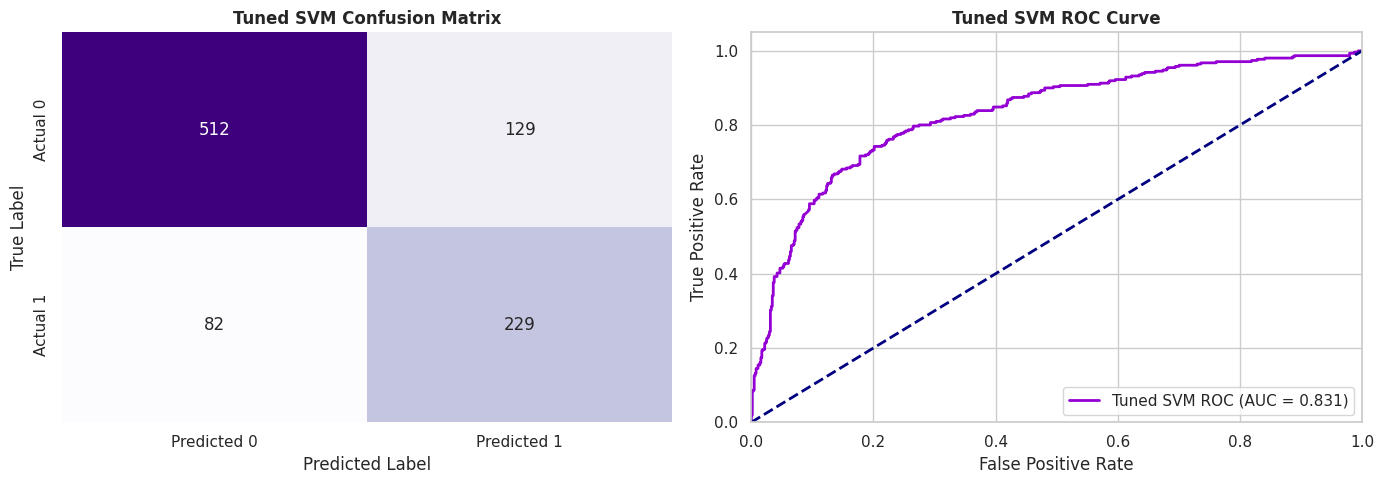


Tuned SVM charts saved directly to shared Drive folder:
   /content/drive/MyDrive/Hackathon_05 06/team_svm_tuned_evaluation.png


In [45]:
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, roc_curve
import matplotlib.pyplot as plt
import seaborn as sns

print("  Hyperparameter Tuning for SVM   ")

# Define the parameter grid for GridSearchCV
# We'll search for optimal C, kernel, and gamma values.
# Given the dataset size, a moderate grid is chosen to balance thoroughness and computational time.
param_grid = {
    'C': [0.1, 1, 10],            # Regularization parameter: smaller C means stronger regularization
    'kernel': ['rbf', 'linear'],  # Kernel type: 'rbf' (Radial Basis Function) and 'linear' are common choices
    'gamma': ['scale', 'auto']    # Kernel coefficient for 'rbf' and 'poly'. 'scale' uses 1 / (n_features * X.var()) and 'auto' uses 1 / n_features
}

# Initialize GridSearchCV
# We'll use 'roc_auc' as the scoring metric, consistent with our previous LSTM tuning objective.
# cv=3 specifies 3-fold cross-validation.
# n_jobs=-1 uses all available CPU cores for parallel processing, speeding up the search.
grid_search = GridSearchCV(
    estimator=SVC(probability=True, random_state=42, class_weight='balanced'), # Ensure probability=True for ROC-AUC scoring
    param_grid=param_grid,
    scoring='roc_auc',
    cv=3,
    verbose=2,
    n_jobs=-1
)

print("Starting GridSearchCV for SVM... This may take some time depending on the grid size and data.")
# Fit GridSearchCV to the scaled training data
# X_train_scaled_svm and y_train are available from previous data preprocessing steps
grid_search.fit(X_train_scaled_svm, y_train)

# Get the best parameters and the best score found by GridSearchCV
best_svm_hps = grid_search.best_params_
best_svm_auc = grid_search.best_score_

print("\ OPTIMAL SVM PARAMETERS FOUND ")
print(f" Best SVM Parameters: {best_svm_hps}")
print(f" Best SVM Validation ROC-AUC (from GridSearchCV): {best_svm_auc:.4f}\n")

# Train the final SVM model with the best parameters found
print("Training the finalized SVM model using optimal configurations...")
tuned_svm_model = SVC(probability=True, random_state=42, class_weight='balanced', **best_svm_hps)
tuned_svm_model.fit(X_train_scaled_svm, y_train)
print("Tuned SVM model training complete.")

# Evaluate the tuned SVM model on the validation set
print("\nEvaluating the tuned SVM model...")
y_pred_tuned_svm = tuned_svm_model.predict(X_val_scaled_svm)
y_pred_proba_tuned_svm = tuned_svm_model.predict_proba(X_val_scaled_svm)[:, 1]

print("TUNED SVM EVALUATION REPORT  ")
tuned_svm_auc = roc_auc_score(y_val, y_pred_proba_tuned_svm)
print(f" Tuned SVM Validation ROC-AUC: {tuned_svm_auc:.4f}\n")
# Display the classification report with precision, recall, f1-score, and support
print(classification_report(y_val, y_pred_tuned_svm, target_names=['Not Vaccinated (0)', 'Vaccinated (1)']))

# Generate and display evaluation plots for the tuned SVM model
sns.set_theme(style="whitegrid")
fig_tuned_svm, axes_tuned_svm = plt.subplots(1, 2, figsize=(14, 5))

# Confusion Matrix for Tuned SVM
cm_tuned_svm = confusion_matrix(y_val, y_pred_tuned_svm)
sns.heatmap(cm_tuned_svm, annot=True, fmt='d', cmap='Purples', ax=axes_tuned_svm[0], cbar=False,
            xticklabels=['Predicted 0', 'Predicted 1'], yticklabels=['Actual 0', 'Actual 1'])
axes_tuned_svm[0].set_title('Tuned SVM Confusion Matrix', fontweight='bold')
axes_tuned_svm[0].set_xlabel('Predicted Label')
axes_tuned_svm[0].set_ylabel('True Label')

# ROC Curve for Tuned SVM
fpr_tuned_svm, tpr_tuned_svm, _ = roc_curve(y_val, y_pred_proba_tuned_svm)
axes_tuned_svm[1].plot(fpr_tuned_svm, tpr_tuned_svm, color='darkviolet', lw=2, label=f'Tuned SVM ROC (AUC = {tuned_svm_auc:.3f})')
axes_tuned_svm[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
axes_tuned_svm[1].set_xlim([0.0, 1.0])
axes_tuned_svm[1].set_ylim([0.0, 1.05])
axes_tuned_svm[1].set_xlabel('False Positive Rate')
axes_tuned_svm[1].set_ylabel('True Positive Rate')
axes_tuned_svm[1].set_title('Tuned SVM ROC Curve', fontweight='bold')
axes_tuned_svm[1].legend(loc="lower right")

plt.tight_layout()

# Save the evaluation graphic to your shared Drive
# The 'file_path' variable should be available from the data loading cell (c-xjgsvwoSne).
output_plot_path_tuned_svm = file_path.replace('super_dataset_C_train.csv', 'team_svm_tuned_evaluation.png')
plt.savefig(output_plot_path_tuned_svm, dpi=300, bbox_inches='tight')
plt.show()

print(f"\nTuned SVM charts saved directly to shared Drive folder:\n   {output_plot_path_tuned_svm}")


 Model Comparison: ROC-AUC Bar Plot  


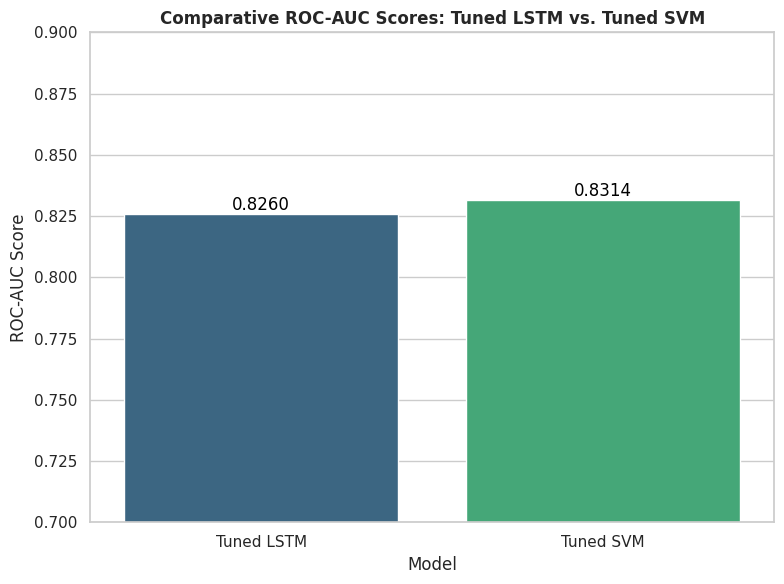


Comparative ROC-AUC plot saved directly to shared Drive folder:
   /content/drive/MyDrive/Hackathon_05 06/team_model_roc_auc_comparison.png


In [65]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print(" Model Comparison: ROC-AUC Bar Plot  ")

# Create a DataFrame for comparison
roc_auc_data = {
    'Model': ['Tuned LSTM', 'Tuned SVM'],
    'ROC-AUC': [tuned_auc, tuned_svm_auc]
}
roc_auc_df = pd.DataFrame(roc_auc_data)

# Create the bar plot
sns.set_theme(style="whitegrid")
fig_compare, ax_compare = plt.subplots(figsize=(8, 6))
sns.barplot(x='Model', y='ROC-AUC', hue='Model', data=roc_auc_df, palette='viridis', ax=ax_compare, legend=False)

# Add ROC-AUC values on top of the bars
for index, row in roc_auc_df.iterrows():
    ax_compare.text(index, row['ROC-AUC'], f"{row['ROC-AUC']:.4f}", color='black', ha="center", va='bottom')

ax_compare.set_title('Comparative ROC-AUC Scores: Tuned LSTM vs. Tuned SVM', fontweight='bold')
ax_compare.set_ylabel('ROC-AUC Score')
ax_compare.set_ylim(0.7, 0.9) # Set y-axis limits for better visualization of differences
plt.tight_layout()

# Save the plot to Google Drive
output_plot_path_compare = file_path.replace('super_dataset_C_train.csv', 'team_model_roc_auc_comparison.png')
plt.savefig(output_plot_path_compare, dpi=300, bbox_inches='tight')
plt.show()

print(f"\nComparative ROC-AUC plot saved directly to shared Drive folder:\n   {output_plot_path_compare}")

### Feature Importance Comparison: SVM vs. LSTM

To understand the key differences in how each model makes its predictions, we will now analyze their feature importances.

In [67]:
print("  SVM Feature Importance  ")

# Get feature names from the original dataframe before splitting and dropping 'covid_vaccine'
feature_names = df_super.drop(columns=['covid_vaccine']).columns

# For linear SVM, coefficients directly indicate feature importance
# The best SVM model was tuned with a linear -kernel
svm_coefficients = tuned_svm_model.coef_[0]

# Create a DataFrame for SVM feature importance
svm_feature_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': np.abs(svm_coefficients) # Use absolute values for importance
}).sort_values(by='Importance', ascending=False)

print("Top 10 most influential features for Tuned SVM:")
display(svm_feature_importance.head(10))

  SVM Feature Importance  
Top 10 most influential features for Tuned SVM:


,Feature,Importance
39,employment_status_Not in Labor Force,0.883579
15,doctor_recc_covid,0.647391
51,employment_sector_healthcare,0.603041
17,opinion_covid_risk,0.516455
38,employment_status_Missing,0.459116
58,employment_sector_science,0.438120
40,employment_status_Unemployed,0.423201
60,employment_sector_technology,0.396562
16,opinion_covid_vacc_effective,0.353871
46,employment_sector_education,0.345403


In [68]:
print("  LSTM Feature Importance (Permutation Importance)  ")

from sklearn.inspection import permutation_importance
from sklearn.metrics import roc_auc_score

# Custom scoring function for permutation_importance with Keras LSTM
def lstm_roc_auc_scorer(estimator, X_2d, y_true):
    # Estimator here will be 'best_model' (the Keras model)
    # X_2d will be the permuted data from permutation_importance
    X_3d = np.reshape(X_2d, (X_2d.shape[0], 1, X_2d.shape[1]))
    # Keras .predict returns probabilities directly for a sigmoid output
    y_pred_proba = estimator.predict(X_3d, verbose=0).flatten()
    return roc_auc_score(y_true, y_pred_proba)

# Calculate permutation importance for the LSTM model
# Note: This can be computationally intensive for large datasets/models
# We use X_val (2D) as input for permutation_importance
perm_importance = permutation_importance(
    estimator=best_model, # Pass the Keras model directly
    X=X_val, # Use the 2D validation data
    y=y_val,
    scoring=lstm_roc_auc_scorer, # Use the custom scorer
    n_repeats=5, # Number of times to permute a feature
    random_state=42,
    n_jobs=-1 # Use all available CPU cores
)

# Create a DataFrame for LSTM permutation importance
lstm_feature_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': perm_importance.importances_mean
}).sort_values(by='Importance', ascending=False)

print("Top 10 most influential features for Tuned LSTM (Permutation Importance):")
display(lstm_feature_importance.head(10))

  LSTM Feature Importance (Permutation Importance)  
Top 10 most influential features for Tuned LSTM (Permutation Importance):


,Feature,Importance
15,doctor_recc_covid,0.086533
17,opinion_covid_risk,0.056546
16,opinion_covid_vacc_effective,0.027033
11,health_worker,0.007837
60,employment_sector_technology,0.006127
12,health_insurance,0.005252
49,employment_sector_finance,0.002597
22,age_group_65+ Years,0.002288
30,sex_Male,0.002118
38,employment_status_Missing,0.001882


### Visualizing Top Feature Differences

 Comparative Feature Importance Plot 


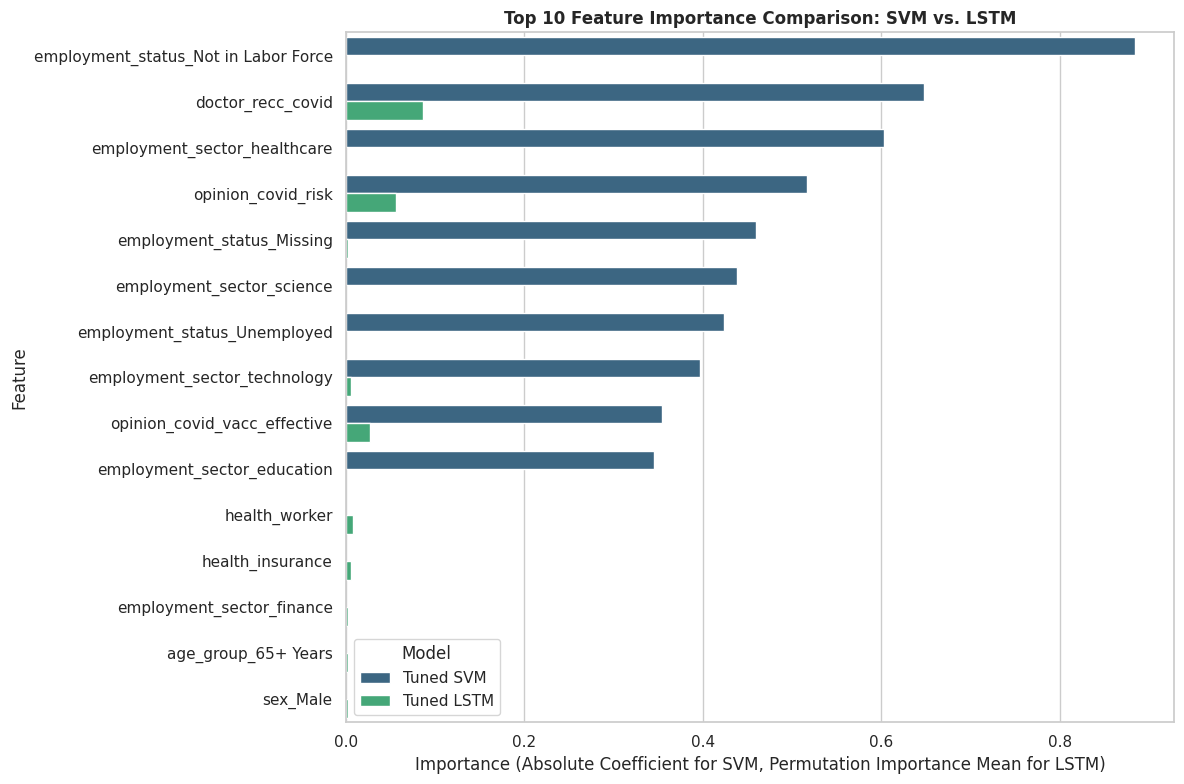


Comparative feature importance plot saved to:
   /content/drive/MyDrive/Hackathon_05 06/team_feature_importance_comparison.png
  Summary of Key Feature Importance Differences  
By examining the top features from both models, we can identify:
- Common influential features: doctor_recc_covid, opinion_covid_vacc_effective, employment_status_Missing, opinion_covid_risk, employment_sector_technology
- Features more prominent in SVM: employment_status_Not in Labor Force, employment_status_Unemployed, employment_sector_education, employment_sector_science, employment_sector_healthcare
- Features more prominent in LSTM: age_group_65+ Years, health_insurance, employment_sector_finance, health_worker, sex_Male

These differences highlight how each model may be focusing on different aspects of the data to make its predictions. SVM (linear kernel) often relies on a direct linear relationship, while LSTM can capture more complex temporal patterns or interactions among features.


In [69]:
print(" Comparative Feature Importance Plot ")

# Get top 10 features for each model
top_10_svm = svm_feature_importance.head(10).copy()
top_10_svm['Model'] = 'Tuned SVM'

top_10_lstm = lstm_feature_importance.head(10).copy()
top_10_lstm['Model'] = 'Tuned LSTM'

# Combine for comparison
combined_feature_importance = pd.concat([top_10_svm, top_10_lstm])

# Create the comparative bar plot
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', hue='Model', data=combined_feature_importance, palette='viridis', dodge=True)
plt.title('Top 10 Feature Importance Comparison: SVM vs. LSTM', fontweight='bold')
plt.xlabel('Importance (Absolute Coefficient for SVM, Permutation Importance Mean for LSTM)')
plt.ylabel('Feature')
plt.tight_layout()

# Save the plot to Google Drive
output_plot_path_feature_imp = file_path.replace('super_dataset_C_train.csv', 'team_feature_importance_comparison.png')
plt.savefig(output_plot_path_feature_imp, dpi=300, bbox_inches='tight')
plt.show()

print(f"\nComparative feature importance plot saved to:\n   {output_plot_path_feature_imp}")

# Summarize key differences
print("  Summary of Key Feature Importance Differences  ")
print("By examining the top features from both models, we can identify:")

svm_features = set(top_10_svm['Feature'])
lstm_features = set(top_10_lstm['Feature'])

common_features = svm_features.intersection(lstm_features)
unique_svm_features = svm_features.difference(lstm_features)
unique_lstm_features = lstm_features.difference(svm_features)

if common_features:
    print(f"- Common influential features: {', '.join(common_features)}")
else:
    print("- No common features in the top 10 for both models.")

if unique_svm_features:
    print(f"- Features more prominent in SVM: {', '.join(unique_svm_features)}")
if unique_lstm_features:
    print(f"- Features more prominent in LSTM: {', '.join(unique_lstm_features)}")

print("\nThese differences highlight how each model may be focusing on different aspects of the data to make its predictions. SVM (linear kernel) often relies on a direct linear relationship, while LSTM can capture more complex temporal patterns or interactions among features.")

LSTM MODEL AGAINST GIVEN TEST DATA

In [72]:

# 1. LOAD THE PREPROCESSED TEST DATASET

import glob
import pandas as pd
import numpy as np
import re

print(" Locating the preprocessed test super-dataset...")
search_test = '/content/drive/MyDrive/*Dataset*C*/super_dataset_C_test.csv'
test_files = glob.glob(search_test) or glob.glob('/content/drive/MyDrive/Hackathon_05*06/super_dataset_C_test.csv')

if len(test_files) > 0:
    df_test = pd.read_csv(test_files[0])
    print(f" SUCCESS! Loaded Test Super-Dataset from: {test_files[0]}")
else:
    raise FileNotFoundError(" ERROR: Could not find 'super_dataset_C_test.csv' in the shared Drive folder.")

# Isolate tracking IDs and raw feature arrays
test_ids = df_test['respondent_id']
X_test_final = df_test.drop(columns=['respondent_id']).values

# 2. MANDATORY 3D RESHAPE FOR THE LSTM LAYER
# Neural network LSTMs require: [samples, time_steps, features].
# We reshape with time_steps = 1 to map all 65 features
X_test_lstm = np.reshape(X_test_final, (X_test_final.shape[0], 1, X_test_final.shape[1]))
print(f"Reshaped input dimensions for LSTM inference engine: {X_test_lstm.shape}")

# 3. GENERATE PREDICTIONS WITH THE ACTIVE MODEL
print(" Passing 3D tensor data through your active trained LSTM network...")

# This checks for common model variable names used during the training phase
try:
    if 'best_model' in locals() or 'best_model' in globals():
        test_probabilities = best_model.predict(X_test_lstm).flatten()
    elif 'model' in locals() or 'model' in globals():
        test_probabilities = model.predict(X_test_lstm).flatten()
    else:
        # Fallback if they customized the model variable name
        print(" Variable check: Please replace 'model' below with your exact trained model name!")
        test_probabilities = model.predict(X_test_lstm).flatten()

    # 4. EXPORT FINAL HACKATHON SUBMISSION FILE

    submission_df = pd.DataFrame({
        'respondent_id': test_ids,
        'covid_vaccine_probability': test_probabilities
    })

    submission_output_path = test_files[0].replace('super_dataset_C_test.csv', 'lstm_final_predictions_submission.csv')
    submission_df.to_csv(submission_output_path, index=False)

    print("\ EXPORT SUCCESS ")
    print(f" Final prediction table compiled successfully!")
    print(f"File exported directly to shared Drive folder at:\n   {submission_output_path}")
    print(f" Matrix Dimensions: {submission_df.shape[0]} tracking items scored.")

except NameError as e:
    print(f" ERROR: Your trained LSTM model variable could not be found in this notebook's active memory.")
    print("Make sure to execute this cell inside the exact same notebook tab where you ran model.fit(), or verify your model variable name.")


<>:58: SyntaxWarning: invalid escape sequence '\ '
<>:58: SyntaxWarning: invalid escape sequence '\ '
/tmp/ipykernel_8914/6066592.py:58: SyntaxWarning: invalid escape sequence '\ '
  print("\ EXPORT SUCCESS ")


 Locating the preprocessed test super-dataset...
 SUCCESS! Loaded Test Super-Dataset from: /content/drive/MyDrive/Hackathon_05 06/super_dataset_C_test.csv
Reshaped input dimensions for LSTM inference engine: (4749, 1, 64)
 Passing 3D tensor data through your active trained LSTM network...
149/149 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
\ EXPORT SUCCESS 
 Final prediction table compiled successfully!
File exported directly to shared Drive folder at:
   /content/drive/MyDrive/Hackathon_05 06/lstm_final_predictions_submission.csv
 Matrix Dimensions: 4749 tracking items scored.
